# Go MPC (Python Wrapper)

This notebook runs the Go implementation and then plots outputs from CSV files.


In [1]:
# %%
%load_ext autoreload
%autoreload 2
import os
import subprocess
import shutil
from pathlib import Path

### Check basic operations

Add, Mult, Rot

In [2]:
import os
import subprocess
import shutil
from pathlib import Path

# Find GoVempc root (works even if this notebook is opened elsewhere)

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_example").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")
# If your environment blocks proxy, uncomment:
# os.environ["GOPROXY"] = "direct"

RUN_TIDY = True  # set False to skip go mod tidy


if RUN_TIDY:
    print("Running: go mod tidy")
    res = subprocess.run(["go", "mod", "tidy"], capture_output=True, text=True)
    if res.stdout:
        print(res.stdout)
    if res.returncode != 0:
        if res.stderr:
            print(res.stderr)

print("Running: go run ./cmd/ckks_example")
res = subprocess.run(["go", "run", "./cmd/ckks_example"], capture_output=True, text=True)
if res.stdout:
    print(res.stdout)
if res.returncode != 0:
    if res.stderr:
        print(res.stderr)


Running: go mod tidy
Running: go run ./cmd/ckks_example
Parameters: {LogN:6 LogNthRoot:0 Q:[] P:[] LogQ:[30 30 30 30] LogP:[30] Xe:<nil> Xs:<nil> RingType:Standard LogDefaultScale:30}
LogN: 6, Ring dimension N: 64
LogQP (bits): 150
Max multiplicative depth (MaxLevel): 3
Default scale (log2): 30
Security note: parameters are tuned for accuracy, not 128-bit security.
Mean encrypt (per ct): 38.745µs
Mean add: 25.51µs
Mean mul+relin+rescale: 0s
Mean rotate: 0s
Mean decrypt+decode (per ct): 42.775µs
Add: [(10.999999997169594-7.34513339040177e-09i) (22.000000002761112-1.411267719353404e-08i) (32.99999998770734+1.6412687708911022e-08i) (44.00000000934375-3.2738631250417427e-09i)]
Mul: [(9.999999992825856-8.651340753593889e-08i) (39.99999994452229-2.525653649424267e-07i) (89.99999989192622+4.1729842971318515e-07i) (160.00000038681847+3.5281203260208865e-07i)]
Rot: [(2.0000000688679096-1.1347672465578107e-07i) (2.9999999587165527-2.6897705375505954e-08i) (4.000000112728944+1.3181219633146002e-0

**What is the plaintext?**

The plaintext is a vector of complex numbers (slots) encoded by CKKS into a polynomial before encryption. In the example, the plaintexts are:

- `valuesA = [1, 2, 3, 4]`
- `valuesB = [10, 20, 30, 40]`

**What operations are performed?**

- **Addition**: `Enc(valuesA) + Enc(valuesB)` (slot-wise addition).
- **Multiplication**: `Enc(valuesA) * Enc(valuesB)` followed by relinearization and rescaling (slot-wise multiplication).
- **Rotation**: `Rotate(Enc(valuesA), +1)` which shifts the slots by 1 position.


### Chebyshev approximation

Expression (power basis):
r(z) = (+2.12226)*z^0 + (+0.5)*z^1 + (+0.02122)*z^2 + (-1.92553e-18)*z^3


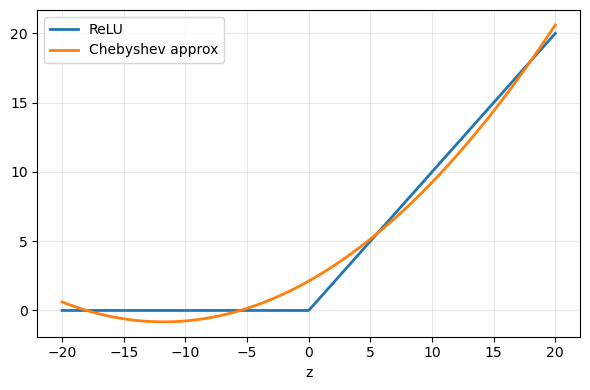

In [3]:
# Chebyshev ReLU approximation used in the variational MPC (order/bound)
import numpy as np
import matplotlib.pyplot as plt

cheb_order = 3
cheb_bound = 20.0
n_samples = max(200, 10 * cheb_order)

# Chebyshev nodes on [-1, 1]
k = np.arange(n_samples)
t_nodes = np.cos(np.pi * (2 * k + 1) / (2 * n_samples))
# Target: ReLU(z) = max(0, z) on [-bound, bound]
y = cheb_bound * np.maximum(0.0, t_nodes)

coeffs = np.polynomial.chebyshev.chebfit(t_nodes, y, deg=cheb_order)
poly_t = np.polynomial.chebyshev.cheb2poly(coeffs)  # in t
# Convert t = z / cheb_bound
poly_z = np.zeros_like(poly_t, dtype=float)
for i, c in enumerate(poly_t):
    poly_z[i] = c / (cheb_bound**i)

# Build string for power basis
pow_terms = [f"({poly_z[i]:+.6g})*z^{i}" for i in range(len(poly_z))]
expr_pow = " + ".join(pow_terms).replace("+ -", "- ")
print("Expression (power basis):")
print("r(z) =", expr_pow)

# Plot
z = np.linspace(-cheb_bound, cheb_bound, 400)
p = np.polynomial.chebyshev.chebval(z/cheb_bound, coeffs)

plt.figure(figsize=(6, 4))
plt.plot(z, np.maximum(0, z), label='ReLU', linewidth=2.0)
plt.plot(z, p, label='Chebyshev approx', linewidth=2.0)
plt.xlabel('z')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Thresholded Chebyshev polynomial

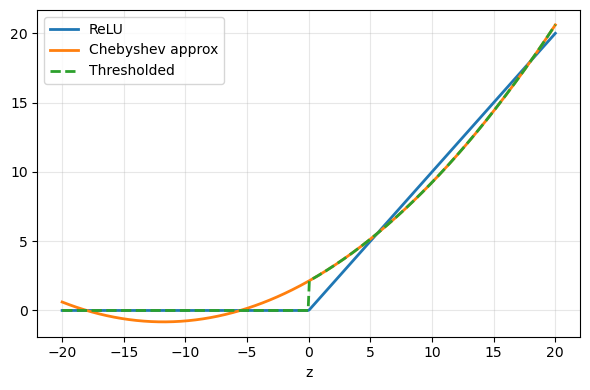

In [4]:
# Thresholded polynomial (as used in the variational MPC)
import numpy as np
import matplotlib.pyplot as plt

# Uses the coeffs/cheb_bound from the previous cell
threshold = np.polynomial.chebyshev.chebval(0.0, coeffs)

z = np.linspace(-cheb_bound, cheb_bound, 400)
p = np.polynomial.chebyshev.chebval(z/cheb_bound, coeffs)

p_thresh = np.where(p < threshold, 0.0, p)

plt.figure(figsize=(6, 4))
plt.plot(z, np.maximum(0, z), label='ReLU', linewidth=2.0)
plt.plot(z, p, label='Chebyshev approx', linewidth=2.0)
plt.plot(z, p_thresh, '--', label='Thresholded', linewidth=2.0)
plt.xlabel('z')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### CKKS evaluation of Chebyshev polynomial

Evaluation of the orange line

Wrote output\cheb_ckks_output.json
Enc: 0.000 ms, Eval: 0.515 ms, Dec: 0.000 ms

CKKS timings (ms): enc=0.000, eval=0.515, dec=0.000


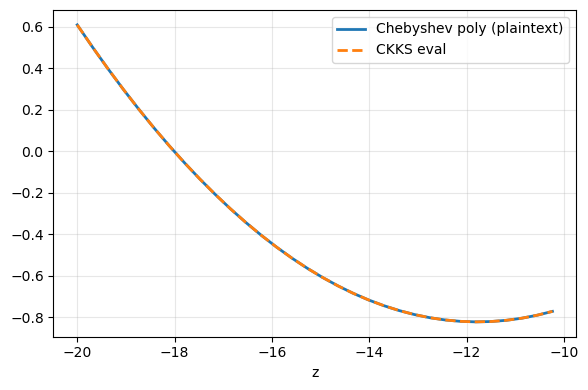

In [5]:
# CKKS evaluation of the Chebyshev polynomial 
import os
import json
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Evaluation grid
z = np.linspace(-cheb_bound, cheb_bound, 128)

# Write input for Go CKKS evaluation
root = Path.cwd()
# Try to locate GoVempc root
if not (root / "go.mod").exists():
    for parent in root.parents:
        if (parent / "go.mod").exists() and (parent / "cmd").exists():
            root = parent
            break

os.chdir(root)
input_path = Path("output") / "cheb_ckks_input.json"
input_path.parent.mkdir(parents=True, exist_ok=True)

payload = {
    "bound": float(cheb_bound),
    "coeffs": [float(c) for c in poly_z.tolist()],  # power basis in z
    "z": [float(v) for v in z.tolist()],
}
input_path.write_text(json.dumps(payload, indent=2))

# Run Go CKKS evaluator (Horner in ciphertext domain)
res = subprocess.run(["go", "run", "./cmd/ckks_cheb_eval"], capture_output=True, text=True)
print(res.stdout)
if res.returncode != 0:
    print(res.stderr)

# Read output
out = json.loads(Path("output/cheb_ckks_output.json").read_text())
ckks_y = np.array(out["y"], dtype=float)
ckks_z = np.array(out["z"], dtype=float)

print(f"CKKS timings (ms): enc={out['time_enc_ms']:.3f}, eval={out['time_eval_ms']:.3f}, dec={out['time_dec_ms']:.3f}")

# Original polynomial in power basis
orig_y = np.polynomial.polynomial.polyval(ckks_z, poly_z)

plt.figure(figsize=(6, 4))
plt.plot(ckks_z, orig_y, label='Chebyshev poly (plaintext)', linewidth=2.0)
plt.plot(ckks_z, ckks_y, '--', label='CKKS eval', linewidth=2.0)
plt.xlabel('z')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



## CKKS MPC

### Offline Phase (`GoVempc/cmd/ckks_offline/main.go`)
This executable demonstrates the offline phase only: the client builds the MPC problem, precomputes matrices, encrypts them with CKKS, and the cloud precomputes cached products with random samples.

1. Build the linearized inverted pendulum model, discretize it, and set the MPC horizon and quadratic cost weights.
2. Assemble box constraints and build the condensed MPC matrices plus the constraint penalty.
3. Compute the variational matrices `L_U` and `Gamma`, then generate CKKS keys and encrypt each row of those matrices.
4. Sample `xi ~ N(0, I)` on the cloud, multiply encrypted rows by plaintext `xi`, and report max absolute errors and timing.

### Online Phase (`GoVempc/cmd/ckks_online/main.go`)
This executable runs the full offline + online protocol, including Chebyshev polynomial evaluation for the encrypted constraint penalty surrogate.

1. Repeat the same MPC and CKKS offline setup as above, but also generate rotation keys and cache `Enc(LU * xi)` and `Enc(Gamma * xi)` for `K` samples.
2. Convert the Chebyshev approximation to power basis and scale it for encrypted polynomial evaluation with Horner's rule.
3. At each time step, the client encrypts `m_U(x_t)` and `b(x_t)`; the cloud combines them with cached samples, evaluates the polynomial, and returns encrypted `U^(i)` and `s_l^(i)`.
4. The client decrypts, thresholds `s_l^(i)`, computes weights, averages controls, applies the first control input, and propagates the state.
5. Trajectories and timing data are written to `output/` as CSV (`xs_ckks.csv`, `us_ckks.csv`, `cloud_ms_ckks.csv`).


In [31]:
# Parameters config
import json
import os
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_offline").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
out = ROOT / "output"
out.mkdir(parents=True, exist_ok=True)

cfg = {
    "m": 0.2,
    "l": 0.5,
    "g": 9.81,
    "dt": 0.01,
    "N": 10, # MPC horizon
    "QDiag": [50.0, 5.0],
    "RDiag": [0.1],
    "QfScale": 2.0,
    # Initial condition
    "x0": [0.3, 0.1],
    # Constraints
    "thetaMax": 0.4,
    "omegaMax": 2.0,
    "uMax": 1.0,
    # Variational mpc parameters
    "sigma0": 0.25,
    "lambda": 0.1,
    # Encryption paramters
    "logN": 13,
    "logQ": [30, 30, 30, 30],
    "logP": [30],
    "logDefaultScale": 30,
    # Number of samples
    "K": 60,
    # Simulation timesteps
    "T": 500,
    "chebOrder": 3,
    "chebBound": 20.0,
    "chebEta": 200.0,
}
(out / "ckks_config.json").write_text(json.dumps(cfg, indent=2))
print("Wrote", out / "ckks_config.json")


Wrote c:\Users\user\OneDrive\Writing\2026\4 CDC Var Enc MPPI\Variational-Encrypted-Model-Predictive-Control\GoVempc\output\ckks_config.json


In [32]:
# Run offline procedure Algorithm 1
import os
import subprocess
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_offline").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")
# If your environment blocks proxy, uncomment:
# os.environ["GOPROXY"] = "direct"

print("Running: go run ./cmd/ckks_offline")
res = subprocess.run(["go", "run", "./cmd/ckks_offline"], capture_output=True, text=True)
if res.stdout:
    print(res.stdout)
if res.returncode != 0 and res.stderr:
    print(res.stderr)




Running: go run ./cmd/ckks_offline
Slot width: 60, slots needed: 3600
CKKS slots: 4096
L_U dims: 10x10
Gamma dims: 60x10
CKKS slots: 4096, K_chunk: 60, T: 500
Cache Enc(L_U * xi): T=500, packed=60 samples per ct
Cache Enc(Gamma * xi): T=500, packed=60 samples per ct
Saved cache to output\ckks_cache
Saved params/keys to output\ckks_cache\crypto
Max abs error (L_U * xi): 2.836e-05
Max abs error (Gamma * xi): 1.030e-04
Client offline time: 720.494 ms
Cloud offline time: 5054397.755 ms



In [33]:
# Run online procedure Algorithm 2
import os
import subprocess
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "ckks_online").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")

proc = subprocess.Popen(
    ["go", "run", "./cmd/ckks_online"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
if proc.stdout is not None:
    for line in proc.stdout:
        print(line, end="")
ret = proc.wait()
if ret != 0:
    print(f"Process exited with code {ret}")



step 0 cloud_ms 43.638
step 1 cloud_ms 44.393
step 2 cloud_ms 42.946
step 3 cloud_ms 41.868
step 4 cloud_ms 42.729
step 5 cloud_ms 44.702
step 6 cloud_ms 44.864
step 7 cloud_ms 46.036
step 8 cloud_ms 41.649
step 9 cloud_ms 42.046
step 10 cloud_ms 41.120
step 11 cloud_ms 42.357
step 12 cloud_ms 39.882
step 13 cloud_ms 42.860
step 14 cloud_ms 42.959
step 15 cloud_ms 44.556
step 16 cloud_ms 40.407
step 17 cloud_ms 40.966
step 18 cloud_ms 40.330
step 19 cloud_ms 39.200
step 20 cloud_ms 39.406
step 21 cloud_ms 40.606
step 22 cloud_ms 41.053
step 23 cloud_ms 40.067
step 24 cloud_ms 40.792
step 25 cloud_ms 43.543
step 26 cloud_ms 41.940
step 27 cloud_ms 39.807
step 28 cloud_ms 41.108
step 29 cloud_ms 40.982
step 30 cloud_ms 41.592
step 31 cloud_ms 39.875
step 32 cloud_ms 42.344
step 33 cloud_ms 43.228
step 34 cloud_ms 42.075
step 35 cloud_ms 40.469
step 36 cloud_ms 41.870
step 37 cloud_ms 40.625
step 38 cloud_ms 39.825
step 39 cloud_ms 39.099
step 40 cloud_ms 40.948
step 41 cloud_ms 39.832
st

In [34]:
# Unencrypted variational MPC
import os
import json
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Locate GoVempc root

def find_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "go.mod").exists() and (p / "cmd" / "test").exists():
            return p
        if (p / "GoVempc" / "go.mod").exists():
            return p / "GoVempc"
    return start

ROOT = find_root(Path.cwd())
os.chdir(ROOT)

os.environ["GOMODCACHE"] = str(ROOT / ".gomodcache")
os.environ["GOCACHE"] = str(ROOT / ".gocache")

cfg_path = ROOT / "output" / "ckks_config.json"
if not cfg_path.exists():
    raise FileNotFoundError("Missing output/ckks_config.json; run the config cell above first.")

print("Running: go run ./cmd/test")
res = subprocess.run(["go", "run", "./cmd/test"], capture_output=True, text=True)
if res.stdout:
    print(res.stdout)
if res.returncode != 0 and res.stderr:
    print(res.stderr)

cfg = json.loads(cfg_path.read_text())
dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

OUT = ROOT / "output"
xs_var = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_var = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)



Running: go run ./cmd/test
Standard MPC
  runtime: 46ms
  cost:    114.747326
  viol:    (x=0.000000, u=0.000000)
Variational MPC
  runtime: 42ms
  cost:    130.828042
  viol:    (x=0.000000, u=0.000000)
  w_sum mean: 59.994000
  accept mean: 59.994000

Saved CSV outputs to output
Saved plots to output\plots



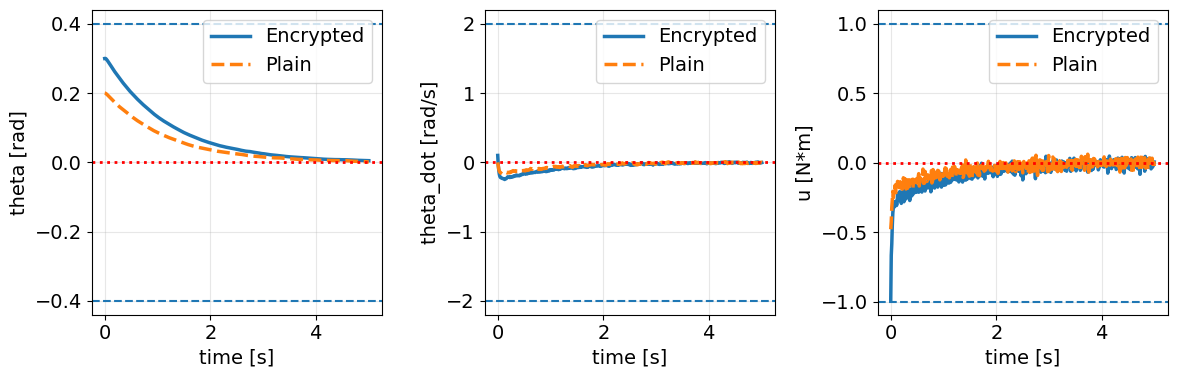

In [35]:
# Overlay encrypted vs plain variational MPC results
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("output")
cfg = json.loads((OUT / "ckks_config.json").read_text())

dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

xs_ckks = np.loadtxt(OUT / "xs_ckks.csv", delimiter=",", ndmin=2)
us_ckks = np.loadtxt(OUT / "us_ckks.csv", delimiter=",", ndmin=2)
xs_plain = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_plain = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)

t_ckks = np.arange(xs_ckks.shape[0]) * dt
t_plain = np.arange(xs_plain.shape[0]) * dt
tu_ckks = np.arange(us_ckks.shape[0]) * dt
tu_plain = np.arange(us_plain.shape[0]) * dt

plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
ax = ax.ravel()

def add_bounds(a, bound):
    a.axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    a.axhline(+bound, linestyle="--")
    a.axhline(-bound, linestyle="--")

# theta
ax[0].plot(t_ckks, xs_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[0].plot(t_plain, xs_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[0], theta_max)
ax[0].set_ylabel("theta [rad]")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# theta_dot
ax[1].plot(t_ckks, xs_ckks[:, 1], label="Encrypted", linewidth=2.5)
ax[1].plot(t_plain, xs_plain[:, 1], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[1], omega_max)
ax[1].set_ylabel("theta_dot [rad/s]")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

# u
ax[2].plot(tu_ckks, us_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[2].plot(tu_plain, us_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[2], u_max)
ax[2].set_ylabel("u [N*m]")
ax[2].grid(True, alpha=0.3)
ax[2].legend()

for a in ax:
    a.set_xlabel("time [s]")

plt.tight_layout()
